In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('student_pass_data.csv')

In [3]:
data.head()

,hours_studied,attendance,passed
0,1,40,0
1,2,55,0
2,2,80,0
3,3,50,0
4,3,65,0


In [4]:
data.isna().sum()

hours_studied    0
attendance       0
passed           0
dtype: int64

In [5]:
X = np.array(data[['hours_studied' ,'attendance']])
Y =np.array(data['passed']).reshape(24,1)

In [6]:
print(f"X(Shape) : {X.shape} , Y(Shape) : {Y.shape}  ")

X(Shape) : (24, 2) , Y(Shape) : (24, 1)  


In [ ]:
# train - test split function
rng = np.random.default_rng(48)
n = X.shape[0]

idx = np.arange(n)
rng.shuffle(idx)



In [8]:
idx

array([18,  6, 13, 22, 10, 11, 17,  1,  3, 12,  2,  9, 16, 21, 19,  5, 14,
        4, 20, 15,  8,  7, 23,  0])

In [9]:
split  = int(0.8 * n)
train_idx = idx[:split]
test_idx = idx[split:]


In [10]:
X_train,X_test = X[train_idx],X[test_idx]
Y_train,Y_test = Y[train_idx],Y[test_idx]

In [11]:
print(f"X_train(Shape) : {X_train.shape} , Y_train(Shape) : {Y_train.shape} , Y_test(Shape) : {Y_test.shape} , X_test(Shape) : {X_test.shape}")

X_train(Shape) : (19, 2) , Y_train(Shape) : (19, 1) , Y_test(Shape) : (5, 1) , X_test(Shape) : (5, 2)


In [ ]:
# normalizing the data
def zscore(X_train):
    Z_mean = np.mean(X_train , axis= 0)
    Z_sigma = np.std(X_train ,axis= 0)
    # z = (X - Z_mean)/Z_sigma
    return  Z_mean,Z_sigma
def apply_scaler(X,mean,sigma):

    return (X- mean) / sigma

In [13]:
mean,std = zscore(X_train)

X_norm  =apply_scaler(X_train, mean,std)
X_test_norm  =apply_scaler(X_test,mean,std)

In [14]:
print(f"Actual X_train : {X_train} , Normalization X_train : {X_norm}")

Actual X_train : [[ 2 45]
 [ 4 72]
 [ 8 95]
 [ 6 50]
 [ 6 78]
 [ 7 90]
 [ 1 90]
 [ 2 55]
 [ 3 50]
 [ 7 68]
 [ 2 80]
 [ 6 62]
 [10 92]
 [ 5 55]
 [ 3 78]
 [ 4 60]
 [ 8 74]
 [ 3 65]
 [ 4 85]] , Normalization X_train : [[-1.15326447 -1.6836663 ]
 [-0.3263956   0.08263393]
 [ 1.32734213  1.58726005]
 [ 0.50047326 -1.35657366]
 [ 0.50047326  0.47514509]
 [ 0.91390769  1.26016741]
 [-1.5666989   1.26016741]
 [-1.15326447 -1.02948103]
 [-0.73983004 -1.35657366]
 [ 0.91390769 -0.17904018]
 [-1.15326447  0.60598214]
 [ 0.50047326 -0.57155134]
 [ 2.15421099  1.39100447]
 [ 0.08703883 -1.02948103]
 [-0.73983004  0.47514509]
 [-0.3263956  -0.70238839]
 [ 1.32734213  0.21347098]
 [-0.73983004 -0.37529576]
 [-0.3263956   0.93307478]]


In [ ]:
# relu activation function
def Relu(X):
    relu = np.maximum(0,X)
    # print(relu)

    return relu

In [16]:
tmp_activation = Relu(X_norm)

In [ ]:
# Sigmoid Activation function
def sigmoid(X):
    err = 1 + np.exp(-X)
    z = 1 / err

    return z

In [18]:
tmp_array = np.array([-2,0,3])
tmp_activation_relu = Relu(tmp_array)
tmp_activation_sigmoid = sigmoid(tmp_array)
print(tmp_activation_sigmoid)
print(tmp_activation_relu)


[0.11920292 0.5        0.95257413]
[0 0 3]


In [ ]:
#input the three layer sizes, output W1, B1, W2, B2
def weights_bias(n_input,n_hidden,n_output):
    rng = np.random.default_rng(42)
    W1 = rng.standard_normal((n_input,n_hidden)) * 0.1
    B1 = np.zeros((1,n_hidden))
    W2 = rng.standard_normal((n_hidden,n_output)) * 0.1
    B2 = np.zeros((1,n_output))
    print(W1.shape)
    return W1,B1,W2,B2


In [20]:
W1,B1,W2,B2 = weights_bias(2,4,1)
print(W1.shape,B1.shape,W2.shape,B2.shape)

(2, 4)
(2, 4) (1, 4) (4, 1) (1, 1)


In [ ]:
# we create input layer and implement the hidden layers includes the output layer
def forward_pass(X,W1,B1,W2,B2):
    err_relu = np.dot(X,W1) + B1
    hidden_layer = Relu(err_relu)
    err_sigmoid = np.dot(hidden_layer,W2) + B2
    output_layer = sigmoid(err_sigmoid)

    return hidden_layer,output_layer

In [22]:
tmp_hidden,tmp_output = forward_pass(X_norm,W1,B1,W2,B2)
print(tmp_hidden.tolist())
print(tmp_output.tolist())


[[0.2933472809908171, 0.3391812468314203, 0.0, 0.0], [0.0, 0.023184203294563537, 0.0, 0.0], [0.0, 0.0, 0.11990214505333849, 0.07464919389422256], [0.2799225702476547, 0.12460181862108985, 0.020215583312536423, 0.08997338624712543], [0.0, 0.0, 0.043632349695716756, 0.03204663756790936], [0.0, 0.0, 0.08469434317242515, 0.04610707214616394], [0.0, 0.0, 0.0, 0.0], [0.16571343305519035, 0.25399458175726053, 0.0, 0.0], [0.2421284103291665, 0.2535913903760278, 0.0, 0.0], [0.06277969726968928, 0.0, 0.06629545529992632, 0.09162094610840514], [0.0, 0.04102791907186097, 0.0, 0.0], [0.12676195272490262, 0.022377820532098084, 0.030251340333899424, 0.06514763681317569], [0.0, 0.0, 0.1794456787086885, 0.15862799927711868], [0.2035075929736786, 0.1250050100023226, 0.0, 0.04074313997077537], [0.0, 0.015068728168380306, 0.0, 0.0], [0.12709261569970245, 0.12540820138355532, 0.0, 0.0], [0.0, 0.0, 0.10233957026595324, 0.11809425540363462], [0.05067763842572631, 0.12581139276478806, 0.0, 0.0], [0.0, 0.0, 0.

In [23]:
print(tmp_hidden.shape)
print(tmp_output.shape)

(19, 4)
(19, 1)


In [ ]:
#It gives us the loss of the forward pass prediction
def binary_cross_entropy(y_true,y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred,eps,1-eps)
    loss = -((y_true*np.log(y_pred)) + (1-y_true) * np.log(1 - y_pred))
    return np.mean(loss)

In [25]:
print(Y_train.shape)
print(tmp_output.shape)

(19, 1)
(19, 1)


In [26]:
loss = binary_cross_entropy(Y_train,tmp_output)
print(loss)

0.6880991804843227


In [27]:
# backward pass

blame_output = tmp_output - Y_train


print(blame_output.shape)

(19, 1)


In [28]:
dW2 = np.dot(tmp_hidden.T,blame_output) / len(X_norm)
dB2 = np.mean(blame_output , axis=0 , keepdims=True)

In [29]:
print(f"dW2(Shape) : {dW2.shape}")
print(f"dB2(Shape) : {dB2.shape}")


dW2(Shape) : (4, 1)
dB2(Shape) : (1, 1)


In [30]:
blame_hidden_layer = np.dot(blame_output,W2.T)
print(blame_hidden_layer.shape)

(19, 4)


In [31]:
relu_mask = tmp_hidden > 0
blame_hidden_relulayer = blame_hidden_layer * relu_mask

In [32]:
blame_hidden_relulayer.shape

(19, 4)

In [33]:
dW1= np.dot(X_norm.T , blame_hidden_relulayer) / len(X_norm)
dW1.shape

(2, 4)

In [34]:
dB1 = np.mean(blame_hidden_relulayer , axis=0 , keepdims=True)
dW2.shape

(4, 1)

In [35]:
print(f"W1 : {dW1.shape} , B1 : {dB1.shape}, W2 : {dW2.shape}, B2 : {dB2.shape}")

W1 : (2, 4) , B1 : (1, 4), W2 : (4, 1), B2 : (1, 1)


In [ ]:
# Using gradient descent we update the parameters which minimize the loss
def update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2,alpha):

    W1 = W1 - alpha * dW1
    B1 = B1 - alpha * dB1
    W2 = W2 - alpha * dW2
    B2 = B2 - alpha * dB2

    return W1,B1,W2,B2


In [37]:
print(binary_cross_entropy(Y_train,tmp_output))

0.6880991804843227


In [38]:
alpha = 0.1
W1_new, B1_new, W2_new, B2_new = update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2 , alpha)


In [39]:
new_hidden,new_output= forward_pass(X_norm,W1_new,B1_new,W2_new,B2_new)
print(binary_cross_entropy(Y_train,new_output))

0.6875777282006759


In [ ]:
#input X, y, W2, hidden result, predictions, output dW1, dB1, dW2, dB2
def backward_pass(X,y,W2,tmp_hidden,tmp_output):
    blame_output = tmp_output - y
    dW2 = np.dot(tmp_hidden.T,blame_output) / len(X)
    dB2 = np.mean(blame_output , axis=0 , keepdims=True)
    blame_hidden_layer = np.dot(blame_output,W2.T)
    relu_mask = tmp_hidden > 0
    blame_hidden_relulayer = blame_hidden_layer * relu_mask
    dW1= np.dot(X.T , blame_hidden_relulayer) / len(X)
    dB1 = np.mean(blame_hidden_relulayer , axis=0 , keepdims=True)


    return dW1,dB1,dW2,dB2

In [41]:
dW1, dB1, dW2, dB2 = backward_pass(X_norm,Y_train,W2_new,new_hidden,new_output,)


In [42]:
print(f"dW1: {dW1.shape} , dB1: {dB1.shape} , dW2: {dW2.shape} , dB2 : {dB2.shape}")

dW1: (2, 4) , dB1: (1, 4) , dW2: (4, 1) , dB2 : (1, 1)


In [ ]:
# it shows the epochs it took , alpha rate and the loss will also be printed out  and updates the parameters
def train(X,y,W1,B1, W2, B2, alpha, epochs):
    losses = []

    for epoch in range(epochs):

        hidden, output = forward_pass(X,W1,B1,W2,B2)
        loss = binary_cross_entropy(y , output)
        losses.append(loss)
        dW1,dB1,dW2,dB2 = backward_pass(X,y,W2 , hidden,output)
        W1,B1,W2,B2 = update_parameters( W1,B1,W2,B2,dW1,dB1,dW2,dB2,alpha)

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} : loss { loss:.4f}")
    # forward_pass = forward_pass(X,W1,B1,W2,B2)
    # binary_cross_entropy = binary_cross_entropy(y,X)
    # backward_pass = backward_pass(X,y,W2_new,new_hidden,new_output)
    # update_parameters = update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2 , alpha)

    # epochs = 100
    return W1,B1,W2,B2,losses

In [44]:
W1_temp,B1_tmp,W2_tmp,B2_tmp, losses = train(X_norm,Y_train,W1,B1,W2,B2,alpha=0.1, epochs=1000)

Epoch    0 : loss 0.6881
Epoch  100 : loss 0.3430
Epoch  200 : loss 0.1995
Epoch  300 : loss 0.1694
Epoch  400 : loss 0.1486
Epoch  500 : loss 0.1294
Epoch  600 : loss 0.1110
Epoch  700 : loss 0.0942
Epoch  800 : loss 0.0798
Epoch  900 : loss 0.0679


In [ ]:
# testing it with the new data
new_students = np.array([
    [2, 45],
    [9, 90],
    [5, 75],
    [6, 55],
    [8, 60],
    [3, 85],
])

In [46]:
X_norm_new = apply_scaler(new_students, mean,std)
X_norm_new

array([[-1.15326447, -1.6836663 ],
       [ 1.74077656,  1.26016741],
       [ 0.08703883,  0.27888951],
       [ 0.50047326, -1.02948103],
       [ 1.32734213, -0.70238839],
       [-0.73983004,  0.93307478]])

In [47]:
hidden , output = forward_pass(X_norm_new,W1_temp,B1_tmp,W2_tmp,B2_tmp)
print(hidden.shape)
print(output.shape)

(6, 4)
(6, 1)


In [48]:
output

array([[3.40298250e-07],
       [9.99999862e-01],
       [9.96045436e-01],
       [1.49125022e-03],
       [3.68715009e-01],
       [9.27868912e-01]])

In [49]:
hidden , output = forward_pass(X_test_norm,W1_temp,B1_tmp,W2_tmp,B2_tmp)
print(hidden.shape)
print(output.shape)

(5, 4)
(5, 1)


In [50]:
output


array([[9.99999814e-01],
       [9.99344743e-01],
       [8.93028872e-01],
       [5.39536561e-01],
       [3.29420009e-08]])

In [ ]:
# convert probabilities to class labels: 1 (pass) if probability >= 0.5, else 0 (fail)
predictions = np.where(output >= 0.5,1,0)
print(predictions.shape)

(5, 1)


In [ ]:
# checking the accuracy
test_acc = np.mean(predictions == Y_test)
test_acc

np.float64(1.0)

In [53]:
print(predictions.shape,Y_test.shape)

(5, 1) (5, 1)


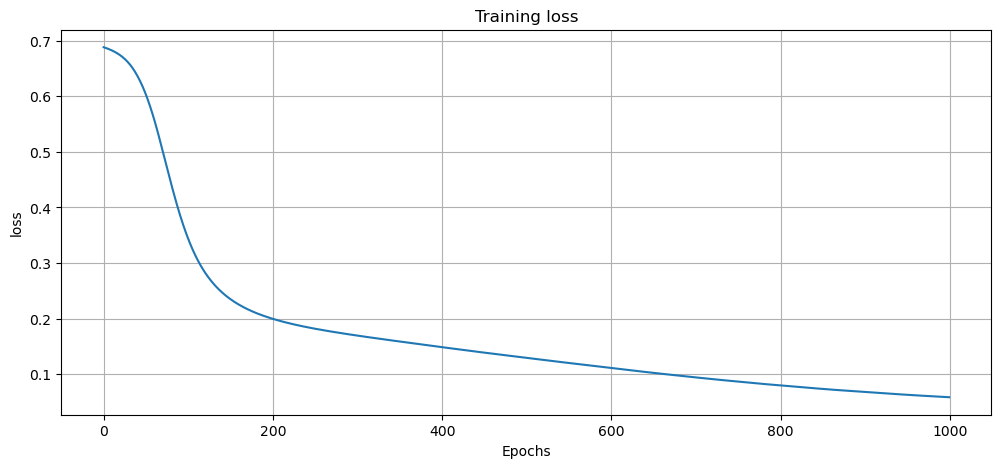

In [ ]:
# plotting the loss
plt.figure(figsize=(12,5))
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid()
plt.show()

In [ ]:
# predict where we can give the input and it shows the prediction 
def my_predict(hours,attendance,mean,std,W1,B1,W2,B2):
    x = np.array([[hours,attendance]])
    x_scaled = apply_scaler(x, mean , std)
    _,prob = forward_pass(x_scaled,W1,B1,W2,B2)
    prob = prob[0,0]
    result = "PASS" if prob >= 0.5  else "FAIL"
    return prob, result

In [62]:
def ask_number(questions, low , high):
    while True:
        try:
            value = float(input(questions))
        except ValueError:
            print("Please enter a number")
            continue
        if low<= value <= high:
            return value
        print(f"Please enter a value from {low} to {high}")
while True:
    hours = ask_number("Hours Studied per day : " , 0 , 24)
    attendance = ask_number("Attendance per today : " , 0 , 100)

    prob, result = my_predict(hours,attendance,mean,std,W1_temp,B1_tmp,W2_tmp,B2_tmp)
    print("Hours Studied : ",hours)
    print("Attendance :",attendance)
    print(f"Probability of the passing : {prob:.2f} , you will probably : {result}")
    if hours > 10 or attendance < 40:
        print("(Note: this is outside the range the model learned from, so treat it with caution.)")

    again = input("\nTry another student? (y/n): ").strip().lower()
    if again != "y":
        break


Hours Studied :  5.0
Attendance : 80.0
Probability of the passing : 1.00 , you will probably : PASS
